In [1]:
from langgraph.graph import StateGraph , END , START
from typing import TypedDict , Annotated

from dotenv import load_dotenv
import os

from langchain_groq import ChatGroq
from pydantic import BaseModel, Field

import operator # Reducer

In [2]:
load_dotenv()
key = os.getenv('GROQ_API_KEY')


llm = ChatGroq(
    model = 'llama-3.3-70b-versatile',
    api_key = key
)

# Form a structured output 

In [15]:
class EvaluationSchema(BaseModel):

    feedback :str = Field(description = "This is the feedback of the essay")
    score : int = Field(description = 'This is the score of the essay between 1 and 10 ')

In [16]:
struct_llm = llm.with_structured_output(EvaluationSchema)

struct_llm.invoke('The ronaldo is the best').score

4

# Create a Class

In [30]:
class UPSC(TypedDict):

    essay : str 
    language_feed : str
    analysis_feed : str 
    clarity_feed : str

    overall_feed : str
    individual_score : Annotated[list[int] , operator.add]

    avg_score : float

In [31]:
def language_feed(state:UPSC) :
    
    essay = state['essay']
    prompt = f"""Give the feedback on the basis of the language used in this essay of UPSC : {essay}"""
    feed = struct_llm.invoke(prompt)

    return {'language_feed' : feed.feedback , 'individual_score' : [feed.score]} 


def clarity_feed(state:UPSC) :
    
    essay = state['essay']
    prompt = f"""Give the feedback on the basis of the calrity in this essay of UPSC : {essay}"""
    feed = struct_llm.invoke(prompt)

    return {'clarity_feed' : feed.feedback , 'individual_score' : [feed.score]}


def analysis_feed(state:UPSC) :
    
    essay = state['essay']
    prompt = f"""Give the feedback on the basis of the in depth analysis in this essay of UPSC : {essay}"""
    feed = struct_llm.invoke(prompt)

    return {'analysis_feed' : feed.feedback , 'individual_score' : [feed.score]}

In [32]:
def overall_feed(state:UPSC):

    prompt = f"""Give me the overall feedback using the language feedback {state['language_feed']} , in depth analysis feedback : 
    {state['analysis_feed']} , and on the basis of the clarity of the essay {state['clarity_feed']}"""

    feed = llm.invoke(prompt).content

    avg_score = sum(state['individual_score'])/3

    return {'overall_feed' : feed , 'avg_score' : avg_score}

In [33]:
graph = StateGraph(UPSC)


# Adding Nodes 


graph.add_node('language_feed' , language_feed)
graph.add_node('analysis_feed' , analysis_feed)
graph.add_node('clarity_feed' , clarity_feed)

graph.add_node('overall_feed' , overall_feed)

In [34]:
# Adding Edges


graph.add_edge(START , 'language_feed')
graph.add_edge(START , 'analysis_feed')
graph.add_edge(START , 'clarity_feed')

graph.add_edge('language_feed' , 'overall_feed')
graph.add_edge('analysis_feed' , 'overall_feed')
graph.add_edge('clarity_feed' , 'overall_feed')

graph.add_edge('overall_feed' , END)

wf = graph.compile()


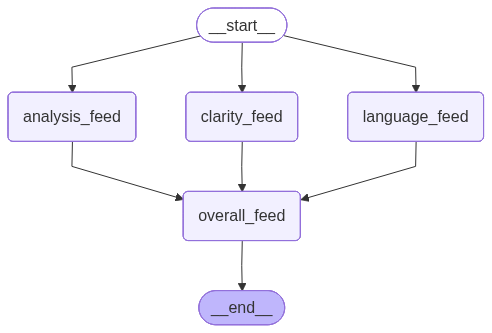

In [35]:
wf

In [44]:
essay2 = """Cristiano Ronaldo dos Santos Aveiro was born on 5 February 1985 in Funchal, Madeira, Portugal. He come from a very poor family, his father was a kit man and his mother was a cook. Nobody at that time think that this small boy from a small island will one day become the most famous athlete in the entire world. But that is exactly what happen.
Ronaldo has scored a record 965 senior career goals for club and country Wikipedia and he is now chasing the 1000 goal milestone which no player in history has ever officially done. This number alone tell you everything about the kind of player he is.
His career started at Sporting CP in Portugal, then he move to Manchester United in 2003. At United, under Sir Alex Ferguson, he completely transform himself. He won three Premier League titles, one Champions League, and one FA Cup FotMob with the club. He was no longer just a tricky winger — he become a complete footballer.
Then come Real Madrid, and that is where Ronaldo truly become a legend. He helped Madrid win La Décima, their tenth European Cup, scoring a penalty in the 120th minute of the final Wikipedia, and in that same season he score a record 17 goals in the Champions League in a single season. He holds the record for most goals in the UEFA Champions League with 140 goals Wikipedia, a record that honestly look impossible to break.
After Real Madrid, he went to Juventus, then return back to Manchester United, and then move to Al Nassr in Saudi Arabia. Many peoples think that going to Saudi Arabia was end of his story. They was wrong. At age 40, Ronaldo tallied eight goals across nine matches in the 2025 UEFA Nations League, including strikes in every knockout stage Grokipedia. He become oldest player to score in Nations League and still helping his country win trophies.
Portugal won two UEFA Nations Leagues, in 2019 and 2025 Wikipedia, and Ronaldo was key in both. He also holds the record for most international goals with 143 goals in 226 appearances Wikipedia — numbers that no other player in mens football has ever come close to.
Off the field, he is the most-followed individual on Instagram with 667 million followers as of November 2025 Grokipedia, making him not just greatest footballer but also biggest digital personality on the planet. He was ranked the world's highest-paid athlete by Forbes on five occasions Wikipedia.
People always debate — Messi or Ronaldo? Both are greatest, both are different. Ronaldo has the better goalscoring record, but Messi has more individual accolades at major tournaments. MessivsRonaldo.app This debate will never have one answer and honestly that is what make football so beautiful.
What make Ronaldo truly special is not just the goals or the trophies. It is the obsession. The man train harder than anyone, sleep in specific ways, eat perfectly, and push himself even at 40 years old when most players retired long time ago. He is proof that talent is just starting point — the work you put in after that is what separate good from legendary.
Cristiano Ronaldo is not just a footballer. He is a idea. He is the proof that if you want something bad enough and work hard enough, the world has no choice but to give it to you."""

In [45]:
input = { 'essay' : essay2}

out = wf.invoke(input)

out


{'essay': "Cristiano Ronaldo dos Santos Aveiro was born on 5 February 1985 in Funchal, Madeira, Portugal. He come from a very poor family, his father was a kit man and his mother was a cook. Nobody at that time think that this small boy from a small island will one day become the most famous athlete in the entire world. But that is exactly what happen.\nRonaldo has scored a record 965 senior career goals for club and country Wikipedia and he is now chasing the 1000 goal milestone which no player in history has ever officially done. This number alone tell you everything about the kind of player he is.\nHis career started at Sporting CP in Portugal, then he move to Manchester United in 2003. At United, under Sir Alex Ferguson, he completely transform himself. He won three Premier League titles, one Champions League, and one FA Cup FotMob with the club. He was no longer just a tricky winger — he become a complete footballer.\nThen come Real Madrid, and that is where Ronaldo truly become a